In [40]:
#Install textblob
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re

In [7]:
# Load dataset
columns = ['sentiment','id','date','query','user','text']
df = pd.read_csv(
    r"C:\Coding_Samurai_Internship\training.1600000.processed.noemoticon.csv\training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=columns,
)
# Display first 5 rows
print(df.head())

   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [8]:
# Select random sample for faster processing
df = df.sample(10000, random_state=42)

In [9]:
# Keep only sentiment label and tweet text
df = df[['sentiment', 'text']]

In [10]:
# Convert positive label from 4 to 1
df['sentiment'] = df['sentiment'].replace(4, 1)
print(df['sentiment'].value_counts())

sentiment
0    5004
1    4996
Name: count, dtype: int64


In [12]:
# Clean tweet
def clean_tweet(text):
    text = re.sub(r'http\S+|www\.\S+', '', str(text))
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.lower().strip()
    return text

df['text'] = df['text'].apply(clean_tweet)

In [13]:
# Function to determine tweet sentiment using TextBlob
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [14]:
# Apply sentiment analysis to all tweets
df["Prediction"] = df["text"].apply(get_sentiment)

In [15]:
# Display sample predictions
print(df[["text", "Prediction"]].head())

                                                     text Prediction
541200                             ahhh i hope your ok!!!   Positive
750            cool , i have no tweet apps  for my razr 2   Positive
766711  i know  just family drama. its lame.hey next t...   Negative
285055  school email won't open  and i have geography ...   Negative
705995                              upper airways problem    Neutral


In [16]:
# Count number of positive, negative and neutral tweets
print(df["Prediction"].value_counts())

Prediction
Positive    4354
Neutral     3572
Negative    2074
Name: count, dtype: int64


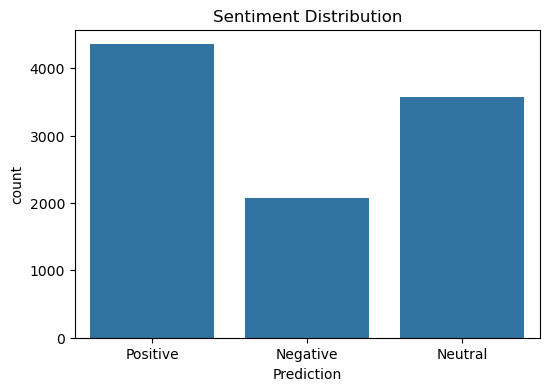

In [17]:
plt.figure(figsize=(6,4))
# Visualize sentiment distribution
sns.countplot(
    x="Prediction",
    data=df
)
plt.title("Sentiment Distribution")
plt.show()

In [18]:
# Convert sentiment categories into numeric labels
df["Predicted_Label"] = df["Prediction"].map({
    "Negative":0,
    "Neutral":0,
    "Positive":1
})

In [19]:
# Compare TextBlob predictions with original dataset labels
accuracy = (
    df["Predicted_Label"] == df["sentiment"]
).mean()
print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 62.4 %


In [20]:
# Display final prediction examples
print(
    df[
        ["text",
         "Prediction"]
    ].head(10)
)

                                                      text Prediction
541200                              ahhh i hope your ok!!!   Positive
750             cool , i have no tweet apps  for my razr 2   Positive
766711   i know  just family drama. its lame.hey next t...   Negative
285055   school email won't open  and i have geography ...   Negative
705995                               upper airways problem    Neutral
379611           going to miss pastor's sermon on faith...   Negative
1189018             on lunch....dj should come eat with me    Neutral
667030                   oh why are you feeling like that?    Neutral
93541       gahh noo!peyton needs to live!this is horrible   Negative
1097326  thank you glad you like it! there is a product...   Positive
